# **Experiment 1: Baseline (No Counterfactual)**
## Question:{q}. Answer:

Loading model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' on cuda...


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:34<00:00, 10.58it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%    CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine   1000   98.9000 1.1000    -10.1112  -17.9577 7.8465 3.3915
  define   1000   98.9000 1.1000    -10.1112  -17.9577 7.8465 3.3915

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 98.90%, Avg CounterFact:  1.10%, Average Log-Fact: -10.1112, Average Log-CFact: -17.9577, Avg Δ: 7.8465

 Results saved to 'premise_word_results.csv'


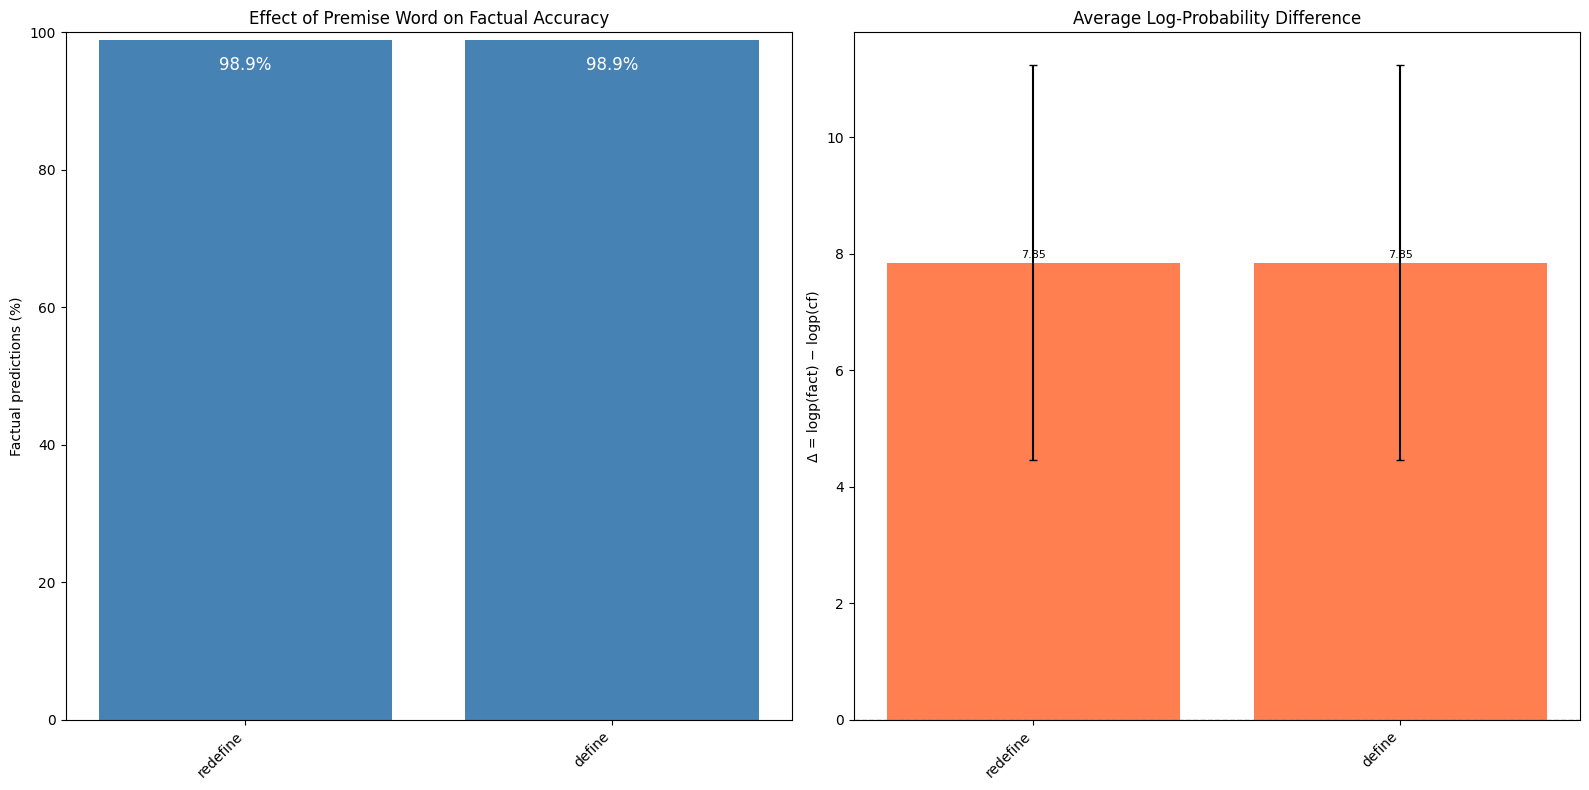

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    f"Question:{q}. "
                    f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Llama 1B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 2.  Context-Only Prompts (ICL Dominant)**
## **Context-Only (Strong):**
## text -> IMPORTANT: You MUST answer using ONLY the information provided below. Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. Treat the text as fully true. Text: "{CF}" Question: {Q} Answer: 


Loading model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:37<00:00, 10.21it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
redefine   1000   48.5000 51.5000    -10.8167  -10.7286 -0.0881 2.2750

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 48.50%, Avg CounterFact: 51.50%, Average Log-Fact: -10.8167, Average Log-CFact: -10.7286, Avg Δ: -0.0881

 Results saved to 'premise_word_results.csv'


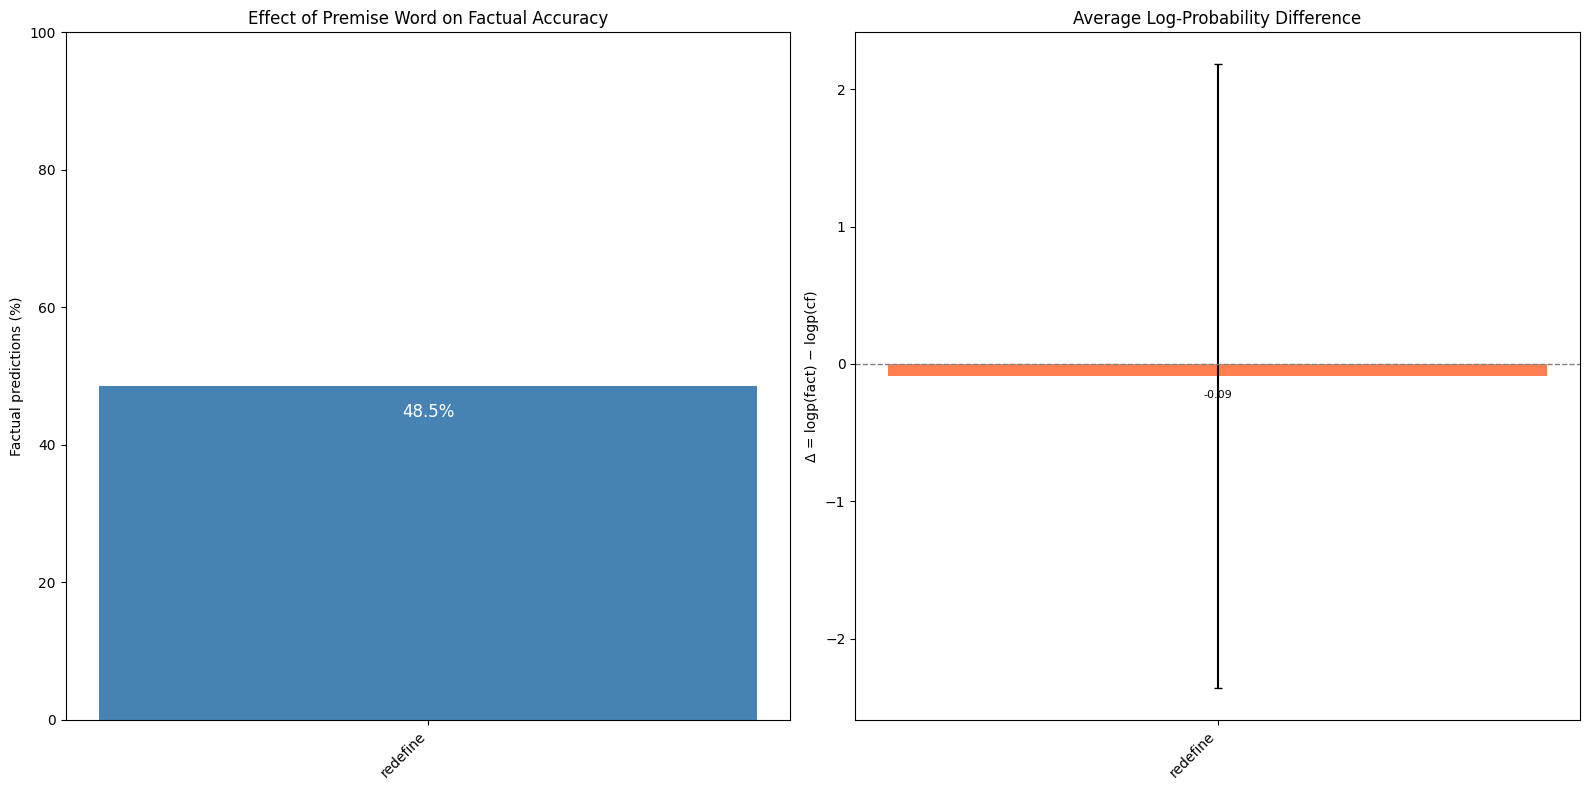

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Llama 1B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 3: Context-Only with Premise Verb**
## **Context-Only + PV:**
## text -> IMPORTANT: You MUST answer using ONLY the information provided below. Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. Treat the text as fully true. Instruction: {PV} Text: "{CF}" Question: {Q} Answer: 


Loading model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [03:38<00:00,  4.58it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000   37.3000 62.7000    -10.3217   -9.7076 -0.6141 2.0375
      define   1000   39.2000 60.8000    -10.3264   -9.7459 -0.5805 2.1345
      verify   1000   38.1000 61.9000    -10.1806   -9.5580 -0.6226 2.1502
  fact check   1000   44.0000 56.0000    -10.2334   -9.9413 -0.2921 2.1518
     suppose   1000   39.7000 60.3000     -9.7942   -9.2854 -0.5088 2.0482
     imagine   1000   33.2000 66.8000    -10.3004   -9.4498 -0.8506 2.0555
       state   1000   34.7000 65.3000    -10.2855   -9.5437 -0.7418 2.0991
according to   1000   39.2000 60.8000     -9.8739   -9.2870 -0.5869 2.0742

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 38.17%, Avg CounterFact: 61.83%, Average Log-Fact: -10.1645, Average Log-CFact: -9.5648, Avg Δ: -0.5997

 Results saved to 'premise_word_results.csv'


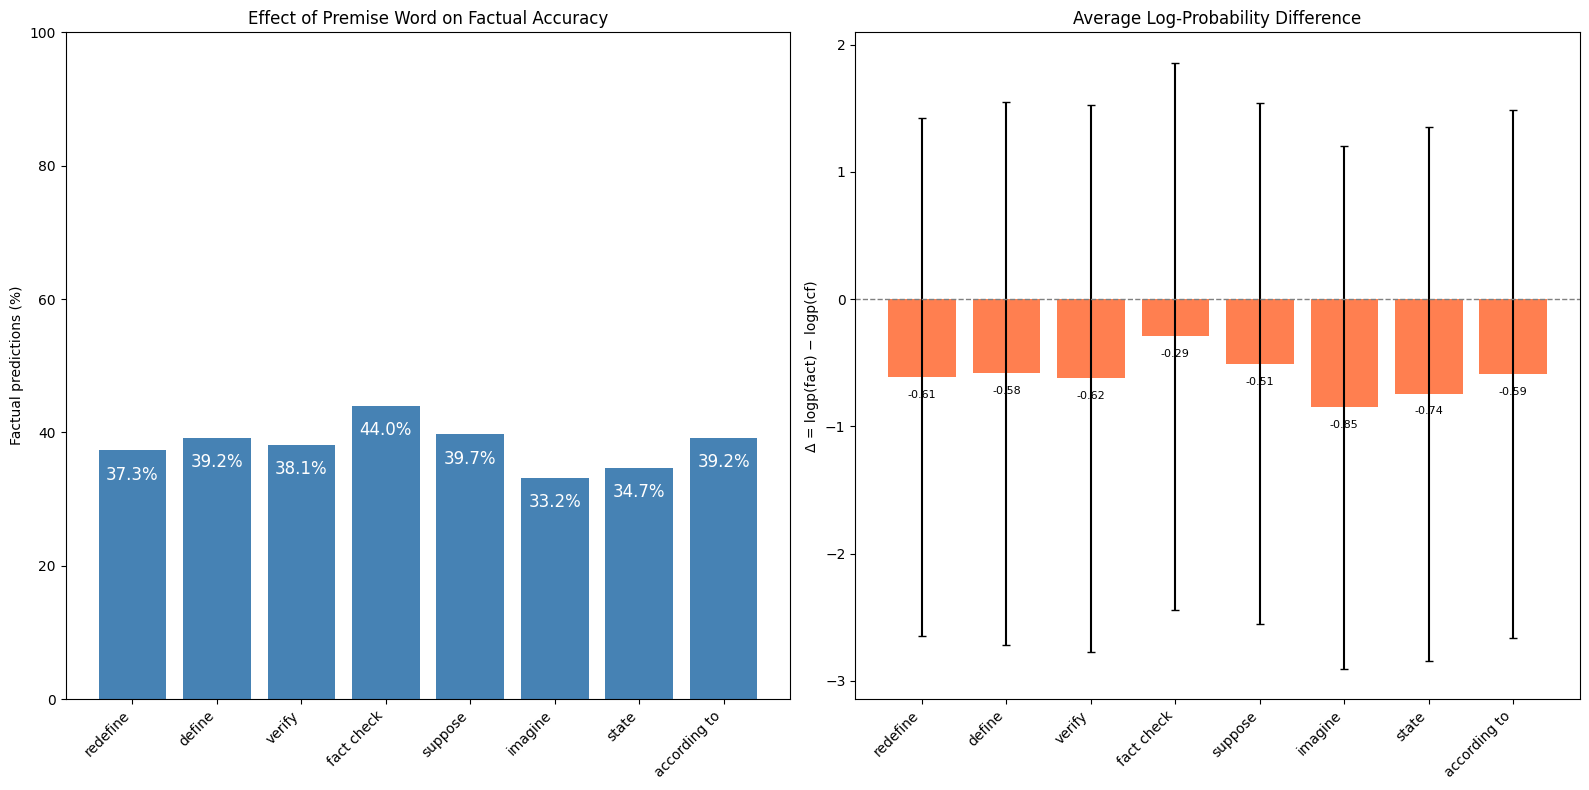

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        'verify', 'fact check',
        
        # Hypothetical:
        'suppose', 'imagine',
        
        # Neutral:
        'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Llama 1B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        max_samples=1000
    )
    analyzer.run()

## All the premises

Loading model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [10:09<00:00,  1.64it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000   37.2000 62.8000    -10.3209   -9.7057 -0.6151 2.0378
      define   1000   39.2000 60.8000    -10.3263   -9.7468 -0.5795 2.1349
        call   1000   32.0000 68.0000    -10.0769   -9.1294 -0.9474 2.0887
        name   1000   30.1000 69.9000    -10.3408   -9.2994 -1.0414 2.1044
characterize   1000   36.7000 63.3000    -10.8217  -10.1224 -0.6993 2.2178
      verify   1000   38.1000 61.9000    -10.1818   -9.5589 -0.6229 2.1512
    validate   1000   36.4000 63.6000    -10.1731   -9.4884 -0.6847 2.1309
  fact check   1000   44.1000 55.9000    -10.2319   -9.9398 -0.2921 2.1516
     confirm   1000   39.3000 60.7000    -10.2135   -9.6361 -0.5774 2.1151
 cross-check   1000   39.6000 60.4000    -10.3983   -9.8479 -0.5504 2.0971
      assess   1000   40.9000 59.1000    -10.6106  -10.1208 -0.4898 2.1770
      review   1000   39.8000 60.2000    -10.2735   -9.7060 -0.5675 2.1940


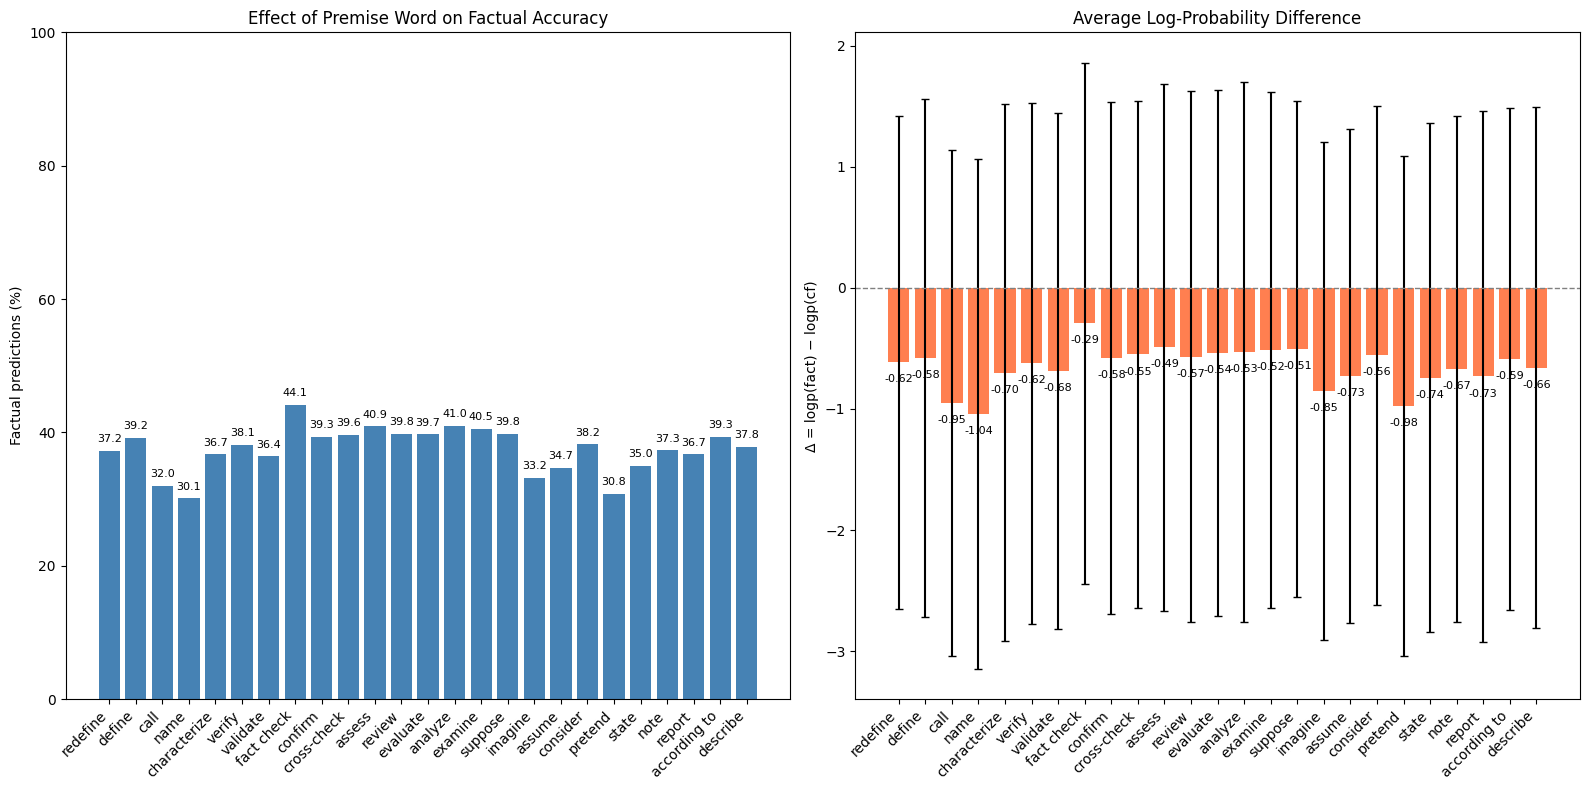

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: You MUST answer using ONLY the information provided below. "
                    f"Do NOT use your own knowledge. Do NOT correct the text even if it contradicts reality. "
                    f"Treat the text as fully true.\n"
                    f"Instruction: {pw}\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='black')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Llama 1B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 4. Memory-Only Prompts (Parametric Memory Dominant)**
## **Memory-Only (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [06:06<00:00,  2.73it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
    redefine   1000    9.2000 90.8000     -9.7475   -7.3516 -2.3959 2.0924
      define   1000   12.3000 87.7000     -9.7183   -7.6413 -2.0770 2.1794
        call   1000    6.0000 94.0000    -10.2306   -7.2161 -3.0145 2.1394
        name   1000    8.6000 91.4000     -9.8165   -7.4614 -2.3551 1.9972
characterize   1000   13.9000 86.1000     -9.9483   -7.9088 -2.0395 2.2395
      verify   1000   12.9000 87.1000     -9.5643   -7.6420 -1.9223 2.0476
    validate   1000    9.0000 91.0000     -9.8530   -7.5405 -2.3125 2.0060
  fact check   1000   30.1000 69.9000     -9.3146   -8.3848 -0.9297 2.0312
     confirm   1000   12.6000 87.4000     -9.7704   -7.8698 -1.9006 1.9806
 cross-check   1000   13.7000 86.3000     -9.2002   -7.3759 -1.8244 1.9108
      assess   1000   14.1000 85.9000     -9.7155   -7.8519 -1.8637 2.0822
      review   1000   14.1000 85.9000     -9.8370   -7.8773 -1.9597 2.1529


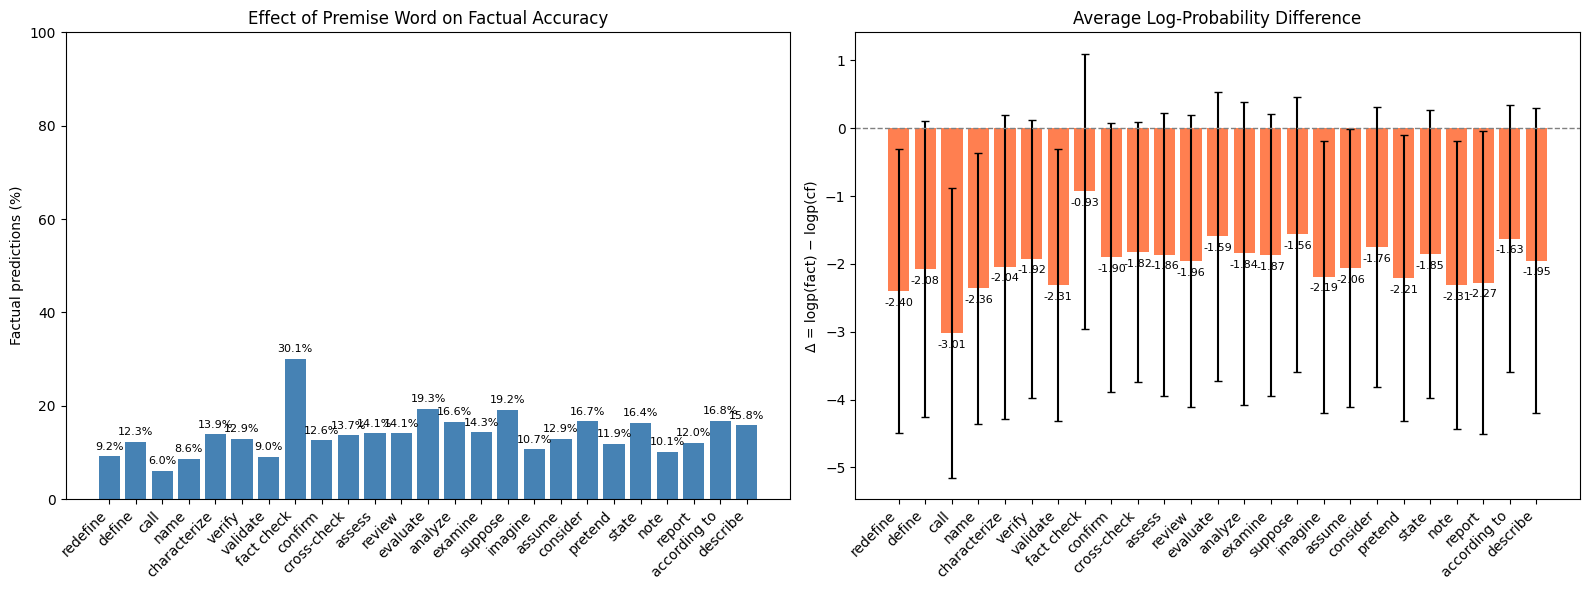

In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']      # includes leading space, e.g., " Africa"
            counterfactual = item['target_new'] # includes leading space, e.g., " Antarctica"

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer the following question.\n"
                    f"Instruction: {pw}\n"
                    f"Text:\n\"{cf}\"\n"
                    f"Question:\n{q}\n"
                    f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<20} {avg_factual:>9.2f}% {avg_cf:>8.2f}% {avg_logp_fact:>12.4f} {avg_logp_cf:>11.4f} {avg_delta:>10.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n✓ Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        # plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        # print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Llama 1B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 4. Memory-Only Prompts (Parametric Memory Dominant)**
## **Memory-Only (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:11<00:00, 13.92it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine   1000   71.0000 29.0000    -10.8297  -11.9558 1.1261 2.2199

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 71.00%, Avg CounterFact: 29.00%, Average Log-Fact: -10.8297, Average Log-CFact: -11.9558, Avg Δ: 1.1261

 Results saved to 'premise_word_results.csv'


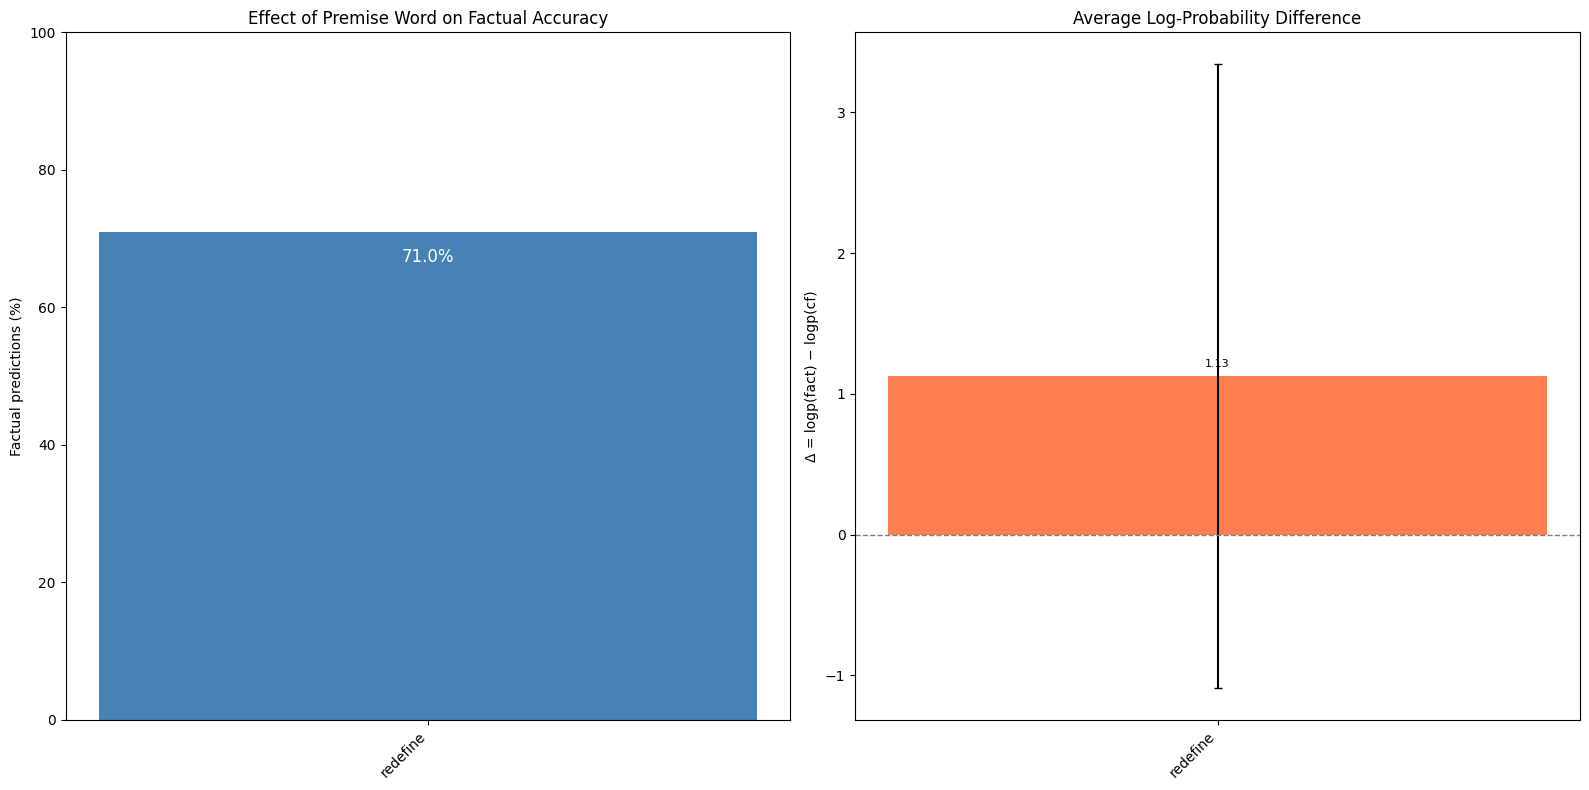

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Llama 1B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 5. Memory-Only with Premise Verb**
## **Memory-Only + PV (Strong)**
## text -> IMPORTANT: Answer using ONLY your own factual world knowledge. Ignore any incorrect or fictional statements below. Instructional verb (may bias behavior): {PV} The following statement is FALSE and must NOT be used: "{CF}" Question: {Q} Answer: 

Loading model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [03:12<00:00,  5.18it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
    redefine   1000   65.6000 34.4000    -10.9294  -11.7840 0.8545 2.0988
      define   1000   67.9000 32.1000    -10.9997  -11.9742 0.9745 2.1608
      verify   1000   65.9000 34.1000    -10.9935  -11.8710 0.8775 2.1456
  fact check   1000   70.2000 29.8000    -11.1712  -12.3280 1.1568 2.1928
     suppose   1000   65.4000 34.6000    -11.0942  -11.9911 0.8968 2.2023
     imagine   1000   68.6000 31.4000    -11.0889  -12.1417 1.0527 2.1745
       state   1000   65.9000 34.1000    -11.2202  -12.1266 0.9064 2.1925
according to   1000   66.8000 33.2000    -11.1435  -12.0705 0.9270 2.1837

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 67.04%, Avg CounterFact: 32.96%, Average Log-Fact: -11.0801, Average Log-CFact: -12.0359, Avg Δ: 0.9558

 Results saved to 'premise_word_results.csv'


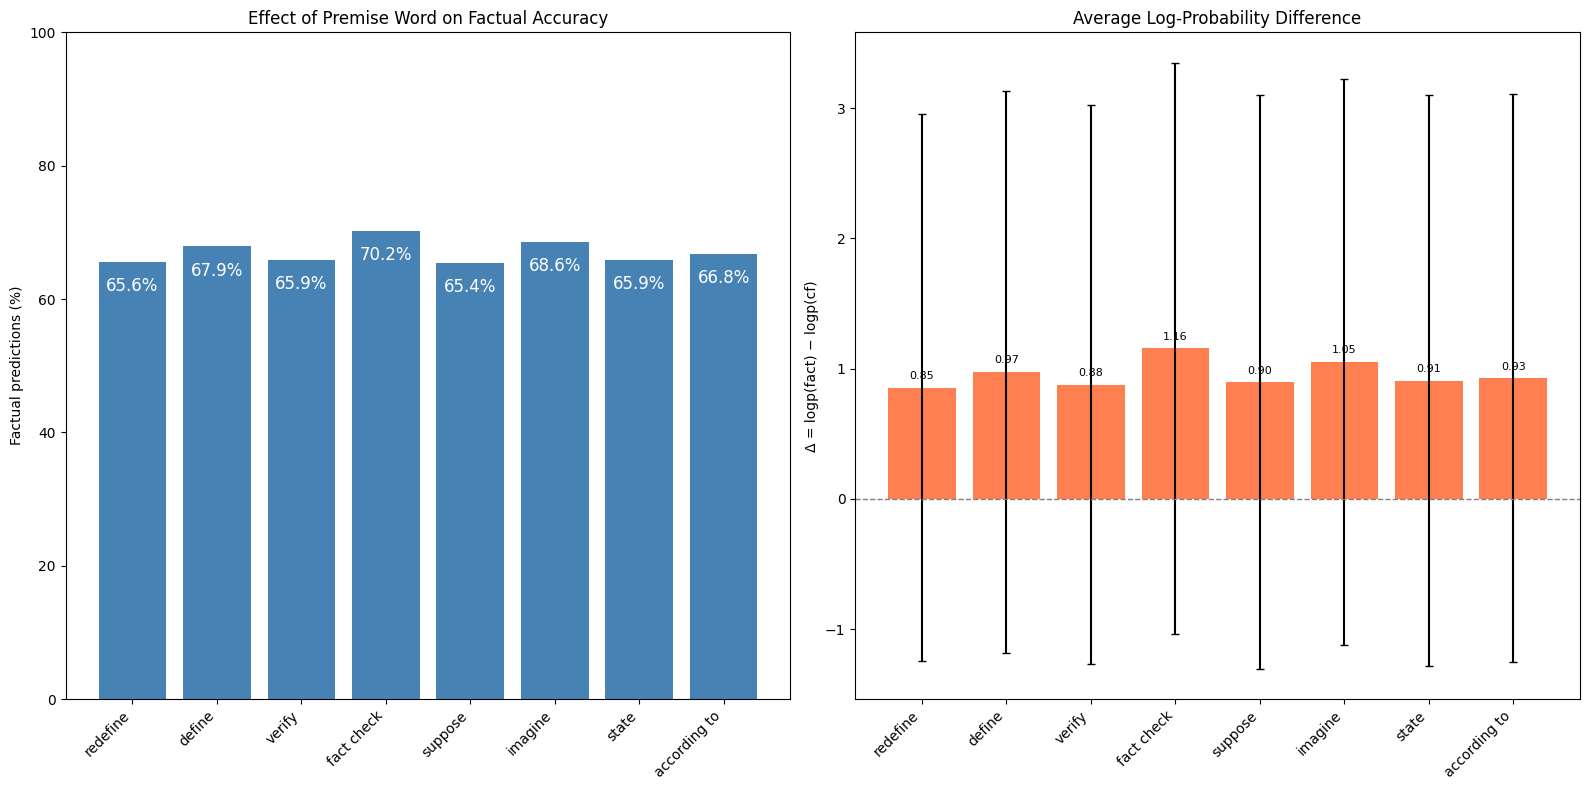

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine', 'define',
        
        # Verification:
        'verify', 'fact check',
        
        # Hypothetical:
        'suppose', 'imagine',
        
        # Neutral:
        'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"Instructional verb (may bias behaviour): {pw} "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Llama 1B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        max_samples=1000
    )
    analyzer.run()

## All the premises

Loading model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [09:36<00:00,  1.73it/s]



EFFECT OF PREMISE WORDS
     Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
    redefine   1000   65.6000 34.4000    -10.9295  -11.7838 0.8543 2.0985
      define   1000   67.6000 32.4000    -10.9988  -11.9722 0.9734 2.1605
        call   1000   68.4000 31.6000    -10.9933  -12.0080 1.0147 2.1500
        name   1000   66.4000 33.6000    -11.1642  -12.0796 0.9155 2.1381
characterize   1000   66.8000 33.2000    -11.0466  -11.9687 0.9220 2.1635
      verify   1000   65.7000 34.3000    -10.9932  -11.8699 0.8767 2.1458
    validate   1000   66.4000 33.6000    -11.0451  -11.9528 0.9076 2.1279
  fact check   1000   70.2000 29.8000    -11.1703  -12.3265 1.1563 2.1923
     confirm   1000   66.3000 33.7000    -11.0702  -11.9706 0.9004 2.1177
 cross-check   1000   68.9000 31.1000    -10.9826  -12.0085 1.0259 2.1097
      assess   1000   68.7000 31.3000    -11.1509  -12.1417 0.9908 2.1201
      review   1000   67.9000 32.1000    -11.1536  -12.1541 1.0005 2.1455
    evaluate 

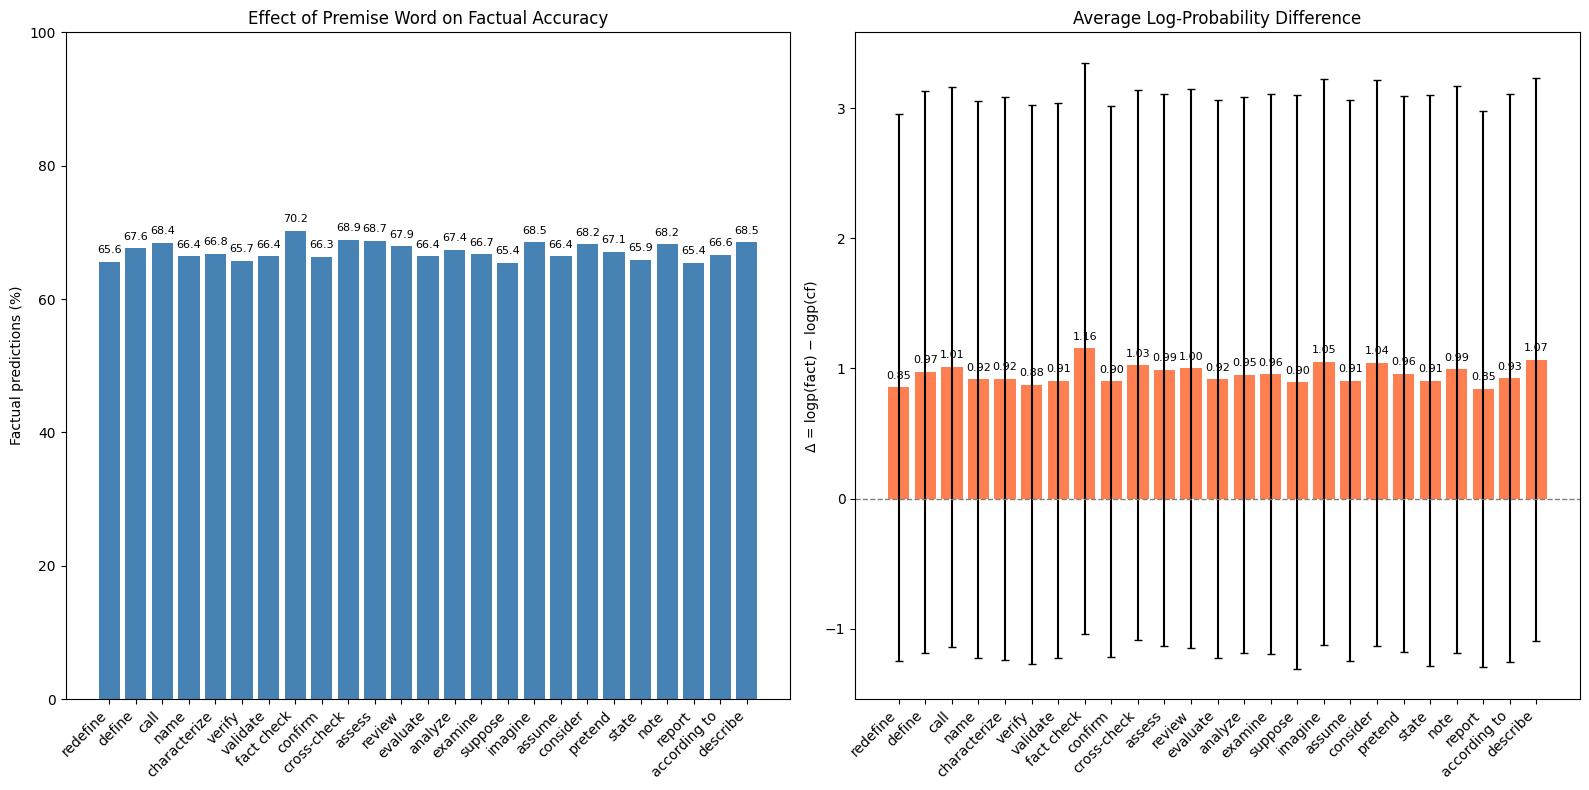

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Definitional / Override
        'redefine', 'define', 'call', 'name', 'characterize',
        # Verification / Fact-Checking
        'verify', 'validate', 'fact check', 'confirm', 'cross-check',
        # Evaluation / Analysis
        'assess', 'review', 'evaluate', 'analyze', 'examine',
        # Hypothetical / Fictional
        'suppose', 'imagine', 'assume', 'consider', 'pretend',
        # Neutral / Reporting
        'state', 'note', 'report', 'according to', 'describe'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"IMPORTANT: Answer using ONLY your own factual world knowledge. "
                    f"Ignore any incorrect or fictional statements below. "
                    f"Instructional verb (may bias behaviour): {pw} "
                    f"The following statement is FALSE and must NOT be used: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{pct:.1f}', ha='center', va='bottom', fontsize=8, color='black')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Llama 1B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 6. Memory-Only (Weak / Competitive)**
## **Memory-Only (Weak):** text -> Answer using your own factual knowledge. Do NOT assume the text below is correct. Text: "{CF}" Question: {Q} Answer: 


Loading model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:10<00:00, 14.28it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)       Δ  Δ Std
redefine   1000   46.9000 53.1000    -10.8752  -10.7700 -0.1051 2.2557

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 46.90%, Avg CounterFact: 53.10%, Average Log-Fact: -10.8752, Average Log-CFact: -10.7700, Avg Δ: -0.1051

 Results saved to 'premise_word_results.csv'


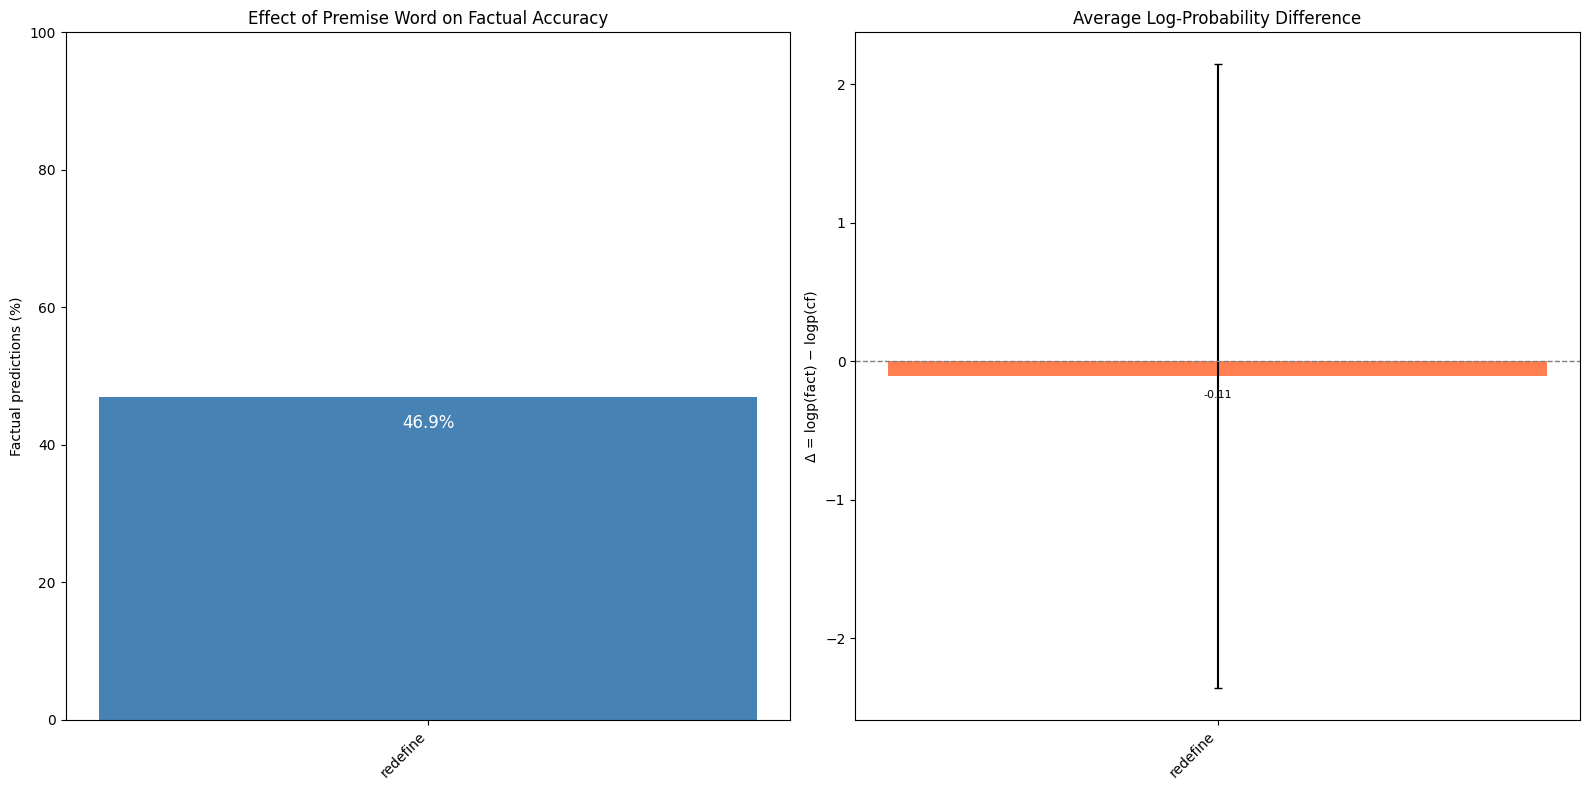

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    f"Answer using your own factual knowledge. Do NOT assume the text below is correct.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Llama 1B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        max_samples=1000
    )
    analyzer.run()

# **Experiment 7. Both Allowed (Natural Competition)**
## Text: "{CF}" Question: {Q} Answer:

Loading model 'TinyLlama/TinyLlama-1.1B-Chat-v1.0' on cuda...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.

Loaded 1000 items.

Running experiment...


Processing items: 100%|██████████| 1000/1000 [01:09<00:00, 14.36it/s]



EFFECT OF PREMISE WORDS
 Premise  Total  Factual%     CF%  LogP(Fact)  LogP(CF)      Δ  Δ Std
redefine   1000   59.2000 40.8000    -10.9194  -11.4890 0.5696 2.4719

-----------------------------------------------------------------------------------------------
AVERAGES        Avg Factual: 59.20%, Avg CounterFact: 40.80%, Average Log-Fact: -10.9194, Average Log-CFact: -11.4890, Avg Δ: 0.5696

 Results saved to 'premise_word_results.csv'


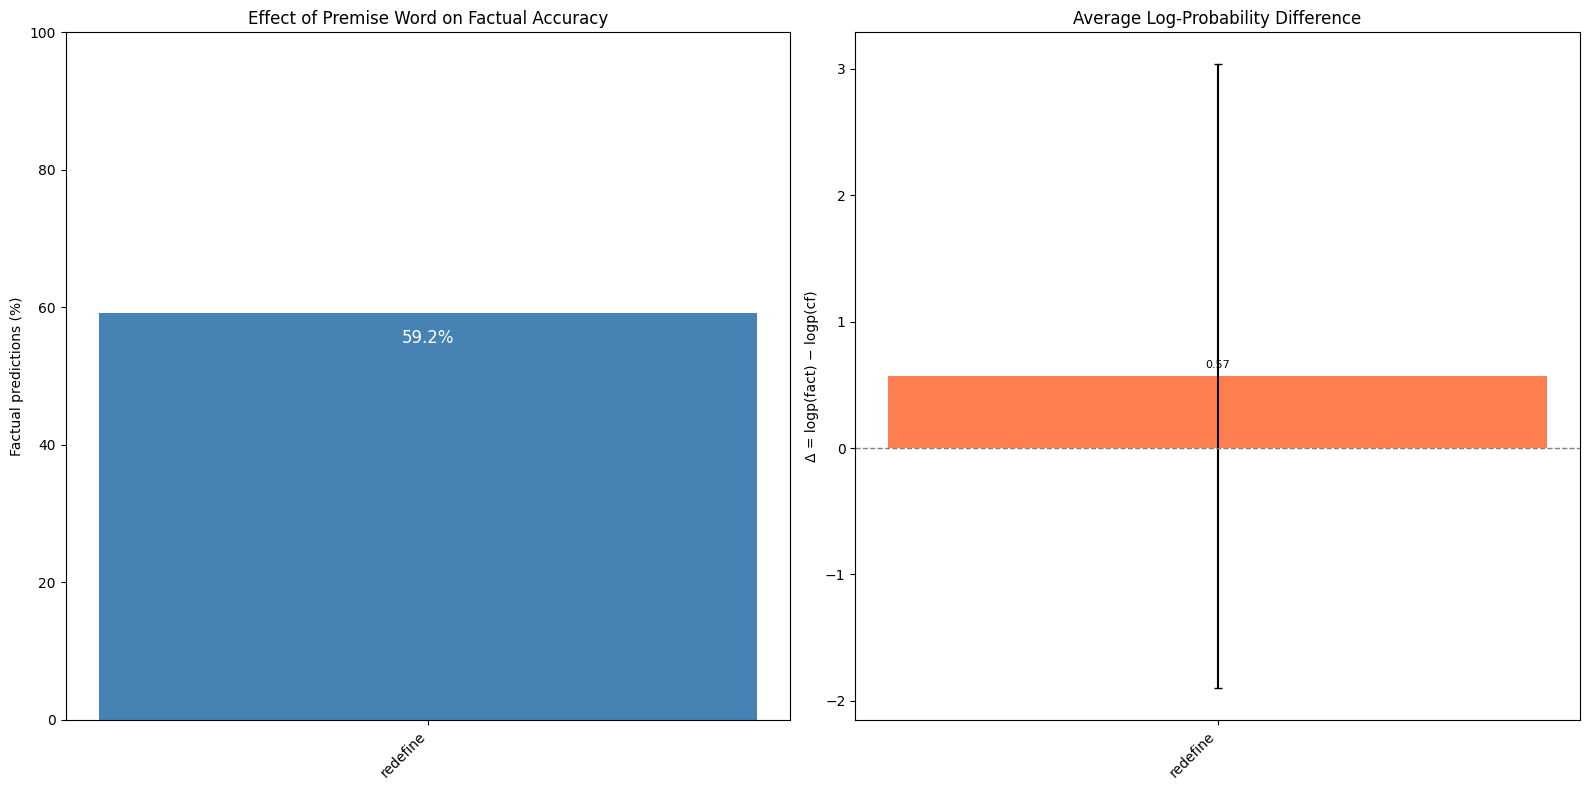

Plot saved as 'premise_word_effect.png'


In [ ]:
import json
import argparse
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict
from tqdm import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

class PremiseWordAnalyzer:
    """
    Evaluate the effect of different premise words (instructions) on a language model's
    tendency to produce factual vs. counterfactual answers.
    """

    # All premise words from Objective II
    PREMISE_WORDS = [
        # Override:
        'redefine',
        
        # Verification:
        # 'verify', 'fact check',
        
        # Hypothetical:
        # 'suppose', 'imagine',
        
        # Neutral:
        # 'state', 'according to'
    ]

    def __init__(self, dataset_path: str, model_name: str, max_samples: int = None):
        self.dataset_path = dataset_path
        self.model_name = model_name
        self.max_samples = max_samples
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = None
        self.model = None
        self.dataset = []          # list of dicts with keys: cf, q, factual, counterfactual
        self.results = {pw: {'total': 0, 'factual': 0, 'counterfactual': 0,
                             'logp_fact_sum': 0.0, 'logp_cf_sum': 0.0,
                             'delta_sum': 0.0, 'delta_sq_sum': 0.0}
                        for pw in self.PREMISE_WORDS}

    def load_model(self):
        """Load tokenizer and model, move to device."""
        print(f"Loading model '{self.model_name}' on {self.device}...")
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if self.device.type == 'cuda' else torch.float32,
            device_map='auto' if self.device.type == 'cuda' else None,
            trust_remote_code=True
        )
        self.model.eval()
        print("Model loaded.\n")

    def load_dataset(self):
        with open(self.dataset_path, 'r') as f:
            data = json.load(f)
        if self.max_samples:
            data = data[:self.max_samples]

        # Transform into our internal format
        for item in data:
            # Validate required keys
            required = {'base_prompt', 'target_new', 'question', 'target_true'}
            if not required.issubset(item.keys()):
                raise KeyError(f"Each dataset item must contain keys: {required}")

            # Build the counterfactual statement (add a period at the end)
            cf = item['base_prompt'].rstrip() + item['target_new'] + "."
            q = item['question']
            factual = item['target_true']
            counterfactual = item['target_new']

            self.dataset.append({
                'cf': cf,
                'q': q,
                'factual': factual,
                'counterfactual': counterfactual
            })

        print(f"Loaded {len(self.dataset)} items.\n")

    def clear_memory(self):
        """Free GPU memory."""
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    def compute_answer_log_probs_batch(self, prompts: List[str], answer: str) -> List[float]:
        """
        For a batch of prompts (same answer for all), compute the log probability
        of the answer string given each prompt.
        Returns a list of log probabilities (one per prompt).
        """
        # Tokenize prompts without special tokens
        prompt_encodings = self.tokenizer(prompts, add_special_tokens=False, padding=False)
        prompt_ids_list = prompt_encodings['input_ids']

        # Tokenize answer (without special tokens)
        answer_ids = self.tokenizer.encode(answer, add_special_tokens=False)
        if not answer_ids:
            return [float('-inf')] * len(prompts)   # empty answer -> impossible

        # Build full input sequences: prompt_ids + answer_ids
        input_ids_list = []
        attention_mask_list = []
        prompt_lengths = []
        for pids in prompt_ids_list:
            full_ids = pids + answer_ids
            input_ids_list.append(full_ids)
            attention_mask_list.append([1] * len(full_ids))
            prompt_lengths.append(len(pids))

        # Pad batch (left padding for causal LM)
        max_len = max(len(ids) for ids in input_ids_list)
        padded_ids = []
        padded_mask = []
        for ids, mask in zip(input_ids_list, attention_mask_list):
            pad_len = max_len - len(ids)
            padded_ids.append([self.tokenizer.pad_token_id] * pad_len + ids)
            padded_mask.append([0] * pad_len + mask)

        input_ids = torch.tensor(padded_ids, device=self.device)
        attention_mask = torch.tensor(padded_mask, device=self.device)

        with torch.no_grad():
            outputs = self.model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # (batch, seq_len, vocab)

        log_probs = []
        for i, (plen, ids) in enumerate(zip(prompt_lengths, input_ids_list)):
            # The answer tokens start at position plen in the *original* unpadded sequence.
            # In the padded batch, the start is (max_len - len(ids)) + plen.
            start = max_len - len(ids) + plen
            ans_log_probs = 0.0
            for j, ans_token_id in enumerate(answer_ids):
                pos = start + j
                # logits at position pos-1 predict token at pos
                logit_vec = logits[i, pos-1, :]
                log_probs_vec = torch.log_softmax(logit_vec, dim=-1)
                ans_log_probs += log_probs_vec[ans_token_id].item()
            log_probs.append(ans_log_probs)

        return log_probs

    def run(self):
        """Main experiment loop."""
        self.load_model()
        self.load_dataset()

        print("Running experiment...")
        for item in tqdm(self.dataset, desc="Processing items"):
            cf = item['cf']
            q = item['q']
            fact_ans = item['factual']
            cf_ans = item['counterfactual']

            # Build prompts for all premise words
            prompts = []
            for pw in self.PREMISE_WORDS:
                prompt = (
                    # f"Answer using your own factual knowledge. Do NOT assume the text below is correct.\n"
                    f"Text: {cf}\n"
                    f"Question: {q}\n"
                    f"Answer:"
                    # f"Answer the following question.\n"
                    # f"Instruction: {pw}\n"
                    # f"Text:\n\"{cf}\"\n"
                    # f"Question:{q}. "
                    # f"Answer:"
                )
                prompts.append(prompt)

            # Compute log probabilities for factual answer and counterfactual answer
            logp_fact_list = self.compute_answer_log_probs_batch(prompts, fact_ans)
            logp_cf_list = self.compute_answer_log_probs_batch(prompts, cf_ans)

            # Update statistics per premise word
            for idx, pw in enumerate(self.PREMISE_WORDS):
                logp_fact = logp_fact_list[idx]
                logp_cf = logp_cf_list[idx]
                delta = logp_fact - logp_cf
                is_factual = logp_fact > logp_cf

                self.results[pw]['total'] += 1
                if is_factual:
                    self.results[pw]['factual'] += 1
                else:
                    self.results[pw]['counterfactual'] += 1
                self.results[pw]['logp_fact_sum'] += logp_fact
                self.results[pw]['logp_cf_sum'] += logp_cf
                self.results[pw]['delta_sum'] += delta
                self.results[pw]['delta_sq_sum'] += delta ** 2

            # Optional: clear cache periodically
            if self.results[self.PREMISE_WORDS[0]]['total'] % 50 == 0:
                self.clear_memory()

        self.compute_summary()
        self.print_table()
        self.save_results()
        self.plot_results()

    def compute_summary(self):
        """Compute percentages and averages for each premise word."""
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            total = r['total']
            if total == 0:
                r['pct_factual'] = 0.0
                r['pct_cf'] = 0.0
                r['avg_logp_fact'] = 0.0
                r['avg_logp_cf'] = 0.0
                r['avg_delta'] = 0.0
                r['std_delta'] = 0.0
            else:
                r['pct_factual'] = (r['factual'] / total) * 100
                r['pct_cf'] = (r['counterfactual'] / total) * 100
                r['avg_logp_fact'] = r['logp_fact_sum'] / total
                r['avg_logp_cf'] = r['logp_cf_sum'] / total
                r['avg_delta'] = r['delta_sum'] / total
                # sample standard deviation
                variance = (r['delta_sq_sum'] / total) - (r['avg_delta'] ** 2)
                r['std_delta'] = np.sqrt(max(variance, 0))

    def print_table(self):
        """Print results table with a final average row."""
        print("\n" + "=" * 95)
        print("EFFECT OF PREMISE WORDS")
        print("=" * 95)

        # Prepare data rows
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'Premise': pw,
                'Total': r['total'],
                'Factual%': r['pct_factual'],
                'CF%': r['pct_cf'],
                'LogP(Fact)': r['avg_logp_fact'],
                'LogP(CF)': r['avg_logp_cf'],
                'Δ': r['avg_delta'],
                'Δ Std': r['std_delta']
            })

        df = pd.DataFrame(rows)
        # Format for printing
        pd.set_option('display.max_rows', None)
        pd.set_option('display.width', 120)
        print(df.to_string(index=False, float_format='%.4f'))

        # Compute averages across premise words
        avg_factual = df['Factual%'].mean()
        avg_cf = df['CF%'].mean()
        avg_logp_fact = df['LogP(Fact)'].mean()
        avg_logp_cf = df['LogP(CF)'].mean()
        avg_delta = df['Δ'].mean()

        print("\n" + "-" * 95)
        print(f"{'AVERAGES':<15} Avg Factual: {avg_factual:>5.2f}%, Avg CounterFact: {avg_cf:>5.2f}%, Average Log-Fact: {avg_logp_fact:>5.4f}, Average Log-CFact: {avg_logp_cf:>5.4f}, Avg Δ: {avg_delta:>5.4f}")
        print("=" * 95)

    def save_results(self):
        """Save detailed results to CSV."""
        rows = []
        for pw in self.PREMISE_WORDS:
            r = self.results[pw]
            rows.append({
                'premise': pw,
                'total_items': r['total'],
                'factual_count': r['factual'],
                'counterfactual_count': r['counterfactual'],
                'pct_factual': r['pct_factual'],
                'pct_counterfactual': r['pct_cf'],
                'avg_logp_factual': r['avg_logp_fact'],
                'avg_logp_counterfactual': r['avg_logp_cf'],
                'avg_delta': r['avg_delta'],
                'std_delta': r['std_delta']
            })
        df = pd.DataFrame(rows)
        df.to_csv('premise_word_results.csv', index=False)
        print("\n Results saved to 'premise_word_results.csv'")

    def plot_results(self):
        """Generate a bar plot for % factual and average Δ."""
        pw_list = self.PREMISE_WORDS
        pct_factual = [self.results[pw]['pct_factual'] for pw in pw_list]
        avg_delta = [self.results[pw]['avg_delta'] for pw in pw_list]
        std_delta = [self.results[pw]['std_delta'] for pw in pw_list]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Left: % factual
        bars1 = ax1.bar(range(len(pw_list)), pct_factual, color='steelblue')
        ax1.set_xticks(range(len(pw_list)))
        ax1.set_xticklabels(pw_list, rotation=45, ha='right')
        ax1.set_ylabel('Factual predictions (%)')
        ax1.set_title('Effect of Premise Word on Factual Accuracy')
        ax1.set_ylim(0, 100)
        for i, (bar, pct) in enumerate(zip(bars1, pct_factual)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() -5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=12, color='white')

        # Right: average Δ with error bars
        ax2.bar(range(len(pw_list)), avg_delta, yerr=std_delta, capsize=3,
                color='coral', error_kw={'ecolor': 'black'})
        ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
        ax2.set_xticks(range(len(pw_list)))
        ax2.set_xticklabels(pw_list, rotation=45, ha='right')
        ax2.set_ylabel('Δ = logp(fact) − logp(cf)')
        ax2.set_title('Average Log‑Probability Difference')
        for i, (delta, std) in enumerate(zip(avg_delta, std_delta)):
            ax2.text(i, delta + (0.05 if delta>=0 else -0.1),
                     f'{delta:.2f}', ha='center', va='bottom' if delta>=0 else 'top', fontsize=8)

        plt.tight_layout()
        plt.savefig('premise_word_effect.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Plot saved as 'premise_word_effect.png'")


if __name__ == '__main__':
    # For direct execution with Llama 1B
    analyzer = PremiseWordAnalyzer(
        dataset_path='/kaggle/input/datasets/animeshlohar/gpt2-with-questions-merged/gpt2_with_questions_merged.json',
        model_name='TinyLlama/TinyLlama-1.1B-Chat-v1.0',
        max_samples=1000
    )
    analyzer.run()